In [5]:
import numpy as np
import cmath
import math
import sympy as sp
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import statistics as stat
import scipy.stats as spstat
import statsmodels.distributions.empirical_distribution as empir

### Oefening 59
Beschouw volgende meetwaarden voor $x$:$$24 \quad 19 \quad 14 \quad 10 \quad 7 \quad 5 \quad 6 \quad 8 \quad 12 \quad 16 \quad 21 \quad 27$$a) Maak een boxplot.

b) Ga na met 95% betrouwbaarheid of (op basis van deze gegevens) $x$ een normale verdeling heeft.

c) Ga na met 95% betrouwbaarheid of (op basis van deze gegevens) $x$ een normale verdeling heeft met $\mu = 7$.

{'whiskers': [<matplotlib.lines.Line2D at 0x1e58d1b3a10>,
 'caps': [<matplotlib.lines.Line2D at 0x1e58d1b3cb0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e58d1b38c0>],
 'medians': [<matplotlib.lines.Line2D at 0x1e58d200050>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e58d2001a0>],
 'means': []}

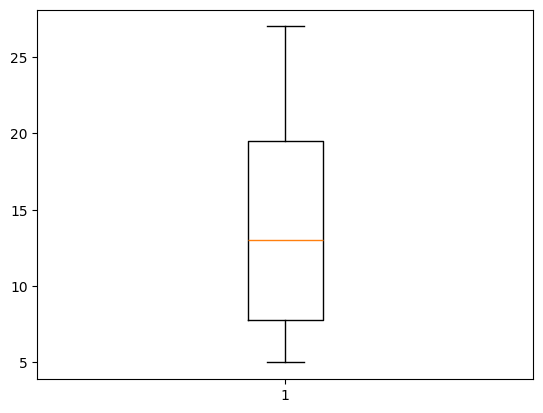

In [2]:
steekproef = [24,19,14,10,7,5,6,8,12,16,21,27]
plt.boxplot(steekproef)

In [3]:
gem = np.mean(steekproef)
print('gemiddelde = ', gem)
s=np.std(steekproef,ddof=1)
print('standaardafwijking = ',s)
D, p = spstat.kstest(steekproef,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D} als teststatistiek, met bijhorende p-waarde {p}.")

gemiddelde =  14.083333333333334
standaardafwijking =  7.366488411390566
De KS-test heeft 0.12887791440863472 als teststatistiek, met bijhorende p-waarde 0.9735582929248066.


In [ ]:
D,p=spstat.kstest(steekproef,spstat.norm(7,s).cdf)
print(f"De KS-test heeft {D} als teststatistiek, met bijhorende p-waarde {p}.")

De KS-test heeft 0.3930033335593103 als teststatistiek, met ibjhorende p-waarde 0.035085631056209876.


### Oefening 67
De afdeling kwaliteitscontrole van een fabriek die microgolfovens maakt, meet bij 42 ovens wat de straling is van de oven met gesloten deuren.

a) Ga na of we er kunnen vanuit gaan dat deze emissie normaal verdeeld is ($\alpha = 0.05$).

b) Ga na of er uitschieters zijn. Welke zijn die?

c) Test of $\mu = 0.1$ met $\alpha = 0.05$.d) Geef een 99% betrouwbaarheidsinterval voor $\mu$.

Data : microgolf.csv

In [6]:
data = pd.read_csv("bestanden/microgolf.csv")
emissie = data["emissie"]

In [7]:
gem=np.mean(emissie)
s=np.std(emissie,ddof=1)
D,p=spstat.kstest(emissie,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D} als teststatistiek, met bijhorende p-waarde {p}.")

De KS-test heeft 0.23029895187837496 als teststatistiek, met bijhorende p-waarde 0.019303873587091402.


uitschieter =  0.4


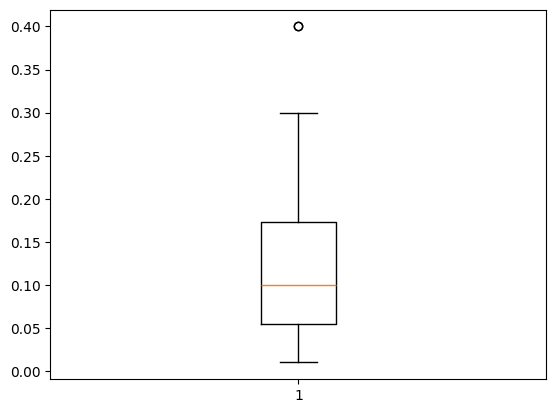

In [8]:
plt.boxplot(emissie)
print("uitschieter = ", np.max(emissie))

In [9]:
t_stat, p_value = spstat.ttest_1samp(emissie,0.1)
print("t-teststatistiek: ",t_stat," met p-waarde: ",p_value)

t-teststatistiek:  1.8313402094971416  met p-waarde:  0.07432279953554637


In [ ]:
interval=spstat.t.interval(0.99,len(emissie)-1,gem,spstat.sem(emissie))
print(interval)

(np.float64(0.08654237069779275), np.float64(0.17012429596887396))


### Oefening 68
Een consumentenorganisatie evalueert de kwaliteit van zonnepanelen. Daarvoor werden op 15 daken panelen geplaatst, één van type A en één van type B. De geleverde stroom (in kWh) werd opgemeten gedurende 3 maanden. Kan op basis van deze gegevens worden geconcludeerd dat er een significant verschil ($\alpha = 0.05$) is op populatieniveau in opgewekte stroom tussen de twee soorten panelen op populatieniveau?

Data : zonnepaneel.csv

In [11]:
data = pd.read_csv("bestanden/zonnepaneel.csv")
typeA = data["A"]
typeB=data["B"]

In [12]:
verschil=typeA-typeB
gem=np.mean(verschil)
s=np.std(verschil,ddof=1)
D,p=spstat.kstest(verschil,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D} als teststatistiek, met bijhorende p-waarde {p}.")

De KS-test heeft 0.12998107435519013 als teststatistiek, met bijhorende p-waarde 0.9332521155909874.


In [13]:
t_stat,p_value = spstat.ttest_rel(typeA,typeB)
print("t-teststatistiek: ",t_stat," met p-waarde: ",p_value)

t-teststatistiek:  -0.9750175708258207  met p-waarde:  0.3460987059225246


### Oefening 69
Een consumentenorganisatie evalueert de kwaliteit van zonnepanelen. Daarvoor wordt op 30 daken één type zonnepaneel gelegd: ofwel type A ofwel type B. De geleverde stroom (in kWh) werd opgemeten gedurende 3 maanden. Kan op basis van deze gegevens worden geconcludeerd dat er een significant verschil is ($\alpha = 0.05$) in opgewekte stroom tussen de twee soorten panelen op populatieniveau? Maak voor beide groepen een box-and-Whisker plot en becommentarieer.

Data: zonnepaneel.csv

In [14]:
data = pd.read_csv("bestanden/zonnepaneel.csv")
typeA = data["A"]
typeB=data["B"]

In [16]:
gemA=np.mean(typeA)
sA=np.std(typeA,ddof=1)
D,p = spstat.kstest(typeA,spstat.norm(gemA,sA).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemB=np.mean(typeB)
sB=np.std(typeB,ddof=1)
D,p = spstat.kstest(typeB,spstat.norm(gemB,sB).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test heeft 0.2884 als teststatistiek, met bijhorende p-waarde 0.1342.
De KS-test heeft 0.1610 als teststatistiek, met bijhorende p-waarde 0.7755.


In [17]:
levene_stat, levene_p = spstat.levene(typeA,typeB,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")

Levene's test: statistiek = 0.0054, p-waarde = 0.9421


In [18]:
t_stat,p_value = spstat.ttest_ind(typeA,typeB)
print(f"t-test statistiek: {t_stat:.4f}, p-waarde: {p_value:.4f}")

t-test statistiek: -0.2934, p-waarde: 0.7714


C:\Users\Talia\AppData\Local\Temp\ipykernel_15976\939276905.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([typeA,typeB],labels=['type A','type B'])


{'whiskers': [<matplotlib.lines.Line2D at 0x1e58d3a7620>,
 'caps': [<matplotlib.lines.Line2D at 0x1e58d3a78c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e58d3a74d0>,
 'medians': [<matplotlib.lines.Line2D at 0x1e58d3a7b60>,
 'fliers': [<matplotlib.lines.Line2D at 0x1e58d3a7cb0>,
 'means': []}

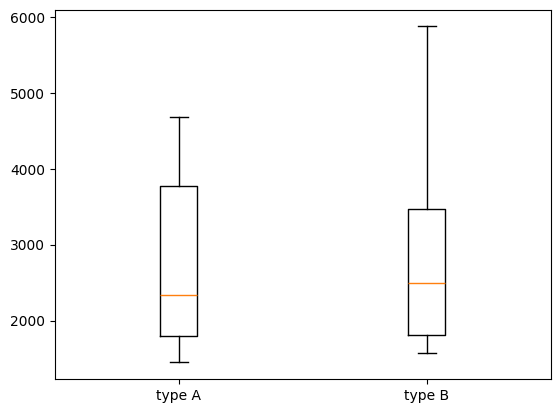

In [19]:
plt.boxplot([typeA,typeB],labels=['type A','type B'])

### Oefening 71
Voor het vervaardigen van synthetisch diamant wordt winst geboekt als de karaat-waarde > 0.5. Een steekproef van 6 diamanten geeft:$$0.46 \quad 0.61 \quad 0.52 \quad 0.48 \quad 0.57 \quad 0.54$$Is algemeen gesproken de productie de moeite waard? Voer een gepaste test uit op 85% niveau.

In [ ]:
data = [0.46,0.61,0.52,0.48,0.57,0.54]
gem=np.mean(data)
s=np.std(data,ddof=1)
D,p = spstat.kstest(data,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test heeft 0.1480 als teststatistiek, met bijhorende p-waarde 0.9966.


In [21]:
t_stat, p_value = spstat.ttest_1samp(data,0.5,alternative='greater')
print(f"t-test statistiek (eenzijdig): {t_stat:.4f}, p-waarde: {p_value:.4f}")

t-test statistiek (eenzijdig): 1.3156, p-waarde: 0.1227


In [22]:
interval = spstat.t.interval(0.70,len(data)-1,gem,spstat.sem(data))
print("70% BI: ", interval)

70% BI:  (np.float64(0.503644449569996), np.float64(0.5563555504300041))


### Oefening 73
De hartslag bij veertien verschillende personen geeft volgende resultaten, waarbij 'hartslag sport' slaat op de resultaten van groep 1 (personen die 2 uren sporten per week), en 'hartslag geen sport' slaat op de resultaten van groep 2 (personen die geen sport doen).
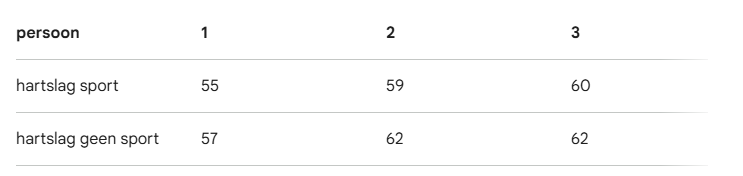
Kan op basis van deze steekproef gesteld worden dat de hartslag op populatieniveau hoger is voor de groep die geen sport doet ($\alpha = 0.05$)?

In [23]:
groep1=[55,59,60,58,61,62,65]
groep2 = [57,62,62,62,60,64,64]
gem1=np.mean(groep1)
s1=np.std(groep1,ddof=1)
D, p = spstat.kstest(groep1,spstat.norm(gem1,s1).cdf)
print(f"De KS-test (voor g1) heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gem2=np.mean(groep2)
s2=np.std(groep2,ddof=1)
D, p = spstat.kstest(groep1,spstat.norm(gem2,s2).cdf)
print(f"De KS-test (voor g2) heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test (voor g1) heeft 0.1207 als teststatistiek, met bijhorende p-waarde 0.9995.
De KS-test (voor g2) heeft 0.3117 als teststatistiek, met bijhorende p-waarde 0.4200.


In [24]:
levene_stat, levene_p = spstat.levene(groep1,groep2,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")

Levene's test: statistiek = 0.3147, p-waarde = 0.5852


In [28]:
t_stat, p_value = spstat.ttest_ind(groep1,groep2,alternative='less')
print(f"t-test statistiek: {t_stat:.4f}, p-waarde: {p_value:.4f}")

t-test statistiek: -1.0410, p-waarde: 0.1592
